# 06 - Geo Clustering

In [1]:
# Cell 1: Setup — load from 05 outputs
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

train_df = pd.read_csv("data/train_final.csv")
test_df = pd.read_csv("data/test_final.csv")

# rebuild engineered features from 05
for df in [train_df, test_df]:
    df['BedBathRatio'] = df['BedroomsTotal'] / df['BathroomsTotalInteger'].replace(0, np.nan)
    df['BedBathRatio'] = df['BedBathRatio'].fillna(df['BedBathRatio'].median())
    df['CloseYear'] = pd.to_datetime(df['CloseDate']).dt.year
    df['PropertyAge'] = (df['CloseYear'] - df['YearBuilt']).clip(lower=0)

drop_from_features = ['ClosePrice', 'ClosePrice_log', 'CloseDate', 'CloseYearMonth', 'CloseYear']
X_train_new = train_df.drop(columns=[c for c in drop_from_features if c in train_df.columns])
X_test_new = test_df.drop(columns=[c for c in drop_from_features if c in test_df.columns])
X_train_new, X_test_new = X_train_new.align(X_test_new, join='left', axis=1, fill_value=0)

y_train = train_df['ClosePrice_log']
y_test = test_df['ClosePrice_log']

print('Feature count:', X_train_new.shape[1])

Feature count: 3999


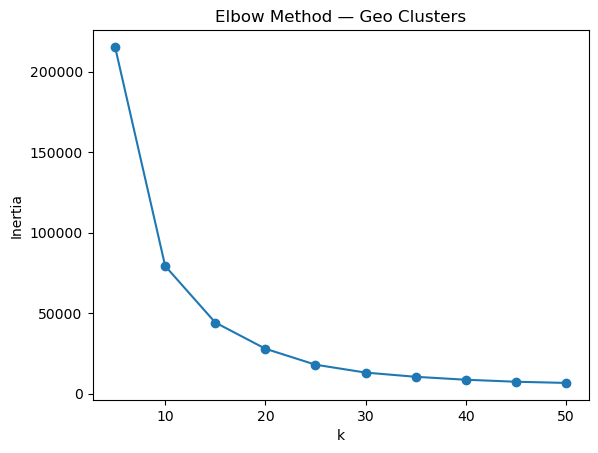

In [2]:
# Cell 2: Elbow method to pick k
# Uses Latitude/Longitude — adjust column names if yours differ
coords_train = train_df[['Latitude', 'Longitude']].dropna()

inertias = []
k_range = range(5, 51, 5)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords_train)
    inertias.append(km.inertia_)

import matplotlib.pyplot as plt
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method — Geo Clusters')
plt.show()

In [3]:
# Cell 3: Fit KMeans with chosen k
# Pick k from the elbow plot above — start with a reasonable guess like 20
K = 20

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(train_df[['Latitude', 'Longitude']])

train_df['LocationCluster'] = kmeans.predict(train_df[['Latitude', 'Longitude']])
test_df['LocationCluster'] = kmeans.predict(test_df[['Latitude', 'Longitude']])

print(train_df['LocationCluster'].value_counts().sort_index())

LocationCluster
0     24317
1     29399
2         2
3        18
4      2044
5     37835
6        27
7         1
8         1
9     23737
10    26660
11    11321
12     5238
13     4497
14     5051
15    12426
16    39213
17     8509
18        5
19        2
Name: count, dtype: int64


In [4]:
# Cell 4: Build new feature set — old + geo cluster (one-hot)
cluster_dummies_train = pd.get_dummies(train_df['LocationCluster'], prefix='GeoCluster')
cluster_dummies_test = pd.get_dummies(test_df['LocationCluster'], prefix='GeoCluster')

X_train_geo = pd.concat([X_train_new.reset_index(drop=True), cluster_dummies_train.reset_index(drop=True)], axis=1)
X_test_geo = pd.concat([X_test_new.reset_index(drop=True), cluster_dummies_test.reset_index(drop=True)], axis=1)

# align in case some clusters missing from test
X_train_geo, X_test_geo = X_train_geo.align(X_test_geo, join='left', axis=1, fill_value=0)

print('Feature count with geo clusters:', X_train_geo.shape[1])

Feature count with geo clusters: 4019


In [8]:
# Cell 5: Train + evaluate RF with geo clusters
rf_geo = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_geo.fit(X_train_geo, y_train)

pred_log = rf_geo.predict(X_test_geo)
pred_price = np.exp(pred_log)
actual_price = np.exp(y_test)

r2_geo = r2_score(y_test, pred_log)
mape_geo = mean_absolute_percentage_error(actual_price, pred_price)
mdape_geo = np.median(np.abs((actual_price - pred_price) / actual_price))

print(f"RF with geo clusters — R²: {r2_geo:.4f}, MAPE: {mape_geo:.4f}, MdAPE: {mdape_geo:.4f}")

RF with geo clusters — R²: 0.8849, MAPE: 0.2344, MdAPE: 0.1033


In [12]:
comparison = pd.DataFrame({
    'Feature Set': ['RF baseline', 'RF + BedBathRatio/PropertyAge', 'RF + Geo Clusters'],
    'R2': [0.8847, 0.8846, r2_geo],
    'MAPE': [0.2343, 0.2345, mape_geo],
    'MdAPE': [0.1036, 0.1038, mdape_geo]
})
print(comparison)

                     Feature Set        R2      MAPE     MdAPE
0                    RF baseline  0.884700  0.234300  0.103600
1  RF + BedBathRatio/PropertyAge  0.884600  0.234500  0.103800
2              RF + Geo Clusters  0.884899  0.234447  0.103254


# 06 - Geo Clustering — Summary

KMeans (k=20) on Latitude/Longitude to create a `LocationCluster` feature, one-hot encoded and added to the Random Forest feature set.

## Results

| Feature Set | R² | MAPE | MdAPE |
|---|---|---|---|
| RF baseline | 0.8847 | 0.2343 | 0.1036 |
| RF + BedBathRatio/PropertyAge | 0.8846 | 0.2345 | 0.1038 |
| RF + Geo Clusters | 0.8849 | 0.2344 | 0.1033 |

## Takeaway

Geo clusters had no measurable effect — all three feature sets perform identically to within 0.0003 on every metric.

This is notable because the high-cardinality location columns (City, PostalCode, SubdivisionName, school districts) were dropped during preprocessing, so the model has limited explicit location signal. Two likely explanations:

- k=20 is too coarse to capture California price variation — cluster sizes ranged from ~39,000 rows down to 2, reflecting the state's uneven population density
- Property-level features such as LivingArea dominate, leaving little variance for location to explain

## Next steps

- Revisit k, or use a density-aware clustering method instead of KMeans
- Reintroduce location columns with a controlled encoding strategy (target or frequency encoding rather than one-hot)
- Investigate the MAPE/MdAPE gap (0.234 vs 0.103) — mean error is more than double the median, indicating a small number of severely mispredicted properties